In [1]:
pip install pandas numpy scipy openpyxl xlrd matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\HP'\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# 1) Imports
import re
from pathlib import Path
from typing import Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from scipy.signal import find_peaks
except Exception:
    find_peaks = None
# %matplotlib inline


In [3]:
# 2) Column mapping tailored to your spreadsheet
CANON_MAP: Dict[str, str] = {
    "zeit": "TIME",
    "bemerkung": "NOTE",
    "u_13_scl": "SCL",
    "u_14_scr": "SCR",
    "u_15_tem": "TEMP",
    "u_16_bvp": "BVP",
    "u_17_pva": "PVA",
    "u_18_puls": "HR",
    "u_19_mot": "MOTION",
}
def canon(col: str) -> str:
    return CANON_MAP.get(str(col).strip().lower(), str(col))


In [4]:
# 3) Time parser for 'Zeit' (HH:MM:SS.f)
TIME_RE = re.compile(r"^(?P<h>\d{1,2}):(?P<m>\d{2}):(?P<s>\d{2})(?:[.,](?P<f>\d+))?$")
def parse_zeit_to_seconds(x) -> Optional[float]:
    if pd.isna(x): return None
    s = str(x).strip()
    m = TIME_RE.match(s)
    if not m: return None
    h = int(m.group("h")); m_ = int(m.group("m")); s_ = int(m.group("s"))
    frac = m.group("f"); f = 0.0 if frac is None else float("0."+frac.replace(",", ""))
    return float(h*3600 + m_*60 + s_) + f


In [5]:
# 4) Simple peak detector (fallback if SciPy missing)
def simple_peaks(x: np.ndarray, height: float | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if find_peaks is not None:
        p, _ = find_peaks(x, height=height); return p
    peaks = []
    for i in range(1, len(x)-1):
        if x[i] > x[i-1] and x[i] > x[i+1] and (height is None or x[i] >= height):
            peaks.append(i)
    return np.asarray(peaks, dtype=int)


In [6]:
# 5) IO helpers: read .csv/.xlsx/.xls and build tidy DataFrame
def read_any(path: str) -> pd.DataFrame:
    ext = Path(path).suffix.lower()
    if ext == ".csv": return pd.read_csv(path)
    if ext in (".xlsx",".xlsm"): return pd.read_excel(path, engine="openpyxl")
    if ext == ".xls": return pd.read_excel(path, engine="xlrd")
    return pd.read_excel(path)
def read_and_tidy(path: str, subject_id: str, session_type: str, method: str | None) -> pd.DataFrame:
    df = read_any(path); df.columns = [canon(c) for c in df.columns]
    if "TIME" in df.columns:
        times = df["TIME"].apply(parse_zeit_to_seconds)
        df = df.loc[times.notna()].copy(); df["timestamp"] = times.loc[times.notna()].astype(float)
    else:
        first = df.columns[0]
        df = df[pd.to_numeric(df[first], errors="coerce").notna()].copy()
        df["timestamp"] = pd.to_numeric(df[first], errors="coerce").astype(float)
    value_cols = [c for c in df.columns if c not in ("TIME","NOTE","timestamp")]
    rows = []; meth = None if (method in ("", "none", None)) else method
    for col in value_cols:
        xs = pd.to_numeric(df[col], errors="coerce").to_numpy(float); ts = df["timestamp"].to_numpy(float)
        mask = ~np.isnan(xs) & ~np.isnan(ts)
        rows.extend([(subject_id, session_type, meth, col, float(t), float(v), path) for t, v in zip(ts[mask], xs[mask])])
    return pd.DataFrame(rows, columns=["subject_id","session_type","method","signal","timestamp","value","file_path"])


In [7]:
# 6) Feature computation
def compute_features(tidy: pd.DataFrame, epoch_s: float | None = None) -> pd.DataFrame:
    if tidy.empty: return pd.DataFrame()
    out = []; keys = ["subject_id","session_type","method","signal"]
    tidy = tidy.sort_values(keys + ["timestamp"])
    for (subj, sess, meth, sig), g in tidy.groupby(keys, dropna=False):
        t = g["timestamp"].to_numpy(float); x = g["value"].to_numpy(float)
        if epoch_s and epoch_s>0:
            bins = np.floor((t - t.min())/epoch_s).astype(int); g = g.assign(epoch=bins); segs = g.groupby("epoch")
        else: segs = [(0, g.assign(epoch=0))]
        for ep, sg in segs:
            ts = sg["timestamp"].to_numpy(float); xs = sg["value"].to_numpy(float)
            dur = float(ts.max()-ts.min()) if ts.size>1 else 0.0
            row = {"subject_id":subj,"session_type":sess,"method":meth,"signal":sig,
                   "epoch": int(ep) if epoch_s else None, "duration_s": dur}
            u = sig.upper()
            if u=="HR":
                row["HR_mean"] = float(np.nanmean(xs))
                row["HR_std"] = float(np.nanstd(xs, ddof=1)) if xs.size>1 else float("nan")
            elif u in ("BVP","PPG","ECG"):
                if dur>0:
                    peaks = simple_peaks(xs, height=np.nanmean(xs))
                    row["HR_est_bpm"] = float((len(peaks)/dur)*60.0) if dur>0 else float("nan")
                    row["peak_count"] = int(len(peaks))
            elif u=="SCL":
                row["SCL_mean"] = float(np.nanmean(xs))
                if ts.size>=2:
                    A = np.vstack([ts, np.ones_like(ts)]).T
                    m, c = np.linalg.lstsq(A, xs, rcond=None)[0]; row["SCL_slope_per_min"] = float(m*60.0)
            elif u=="SCR":
                pos = np.maximum(xs, 0.0)
                row["SCR_pos_area"] = float(np.trapz(pos, x=ts)) if ts.size>1 else float(np.nansum(pos))
                row["SCR_mean"] = float(np.nanmean(xs))
            elif u=="PVA":
                row["PVA_mean"] = float(np.nanmean(xs))
                row["PVA_std"]  = float(np.nanstd(xs, ddof=1)) if xs.size>1 else float("nan")
            elif u=="TEMP":
                row["Temp_mean"] = float(np.nanmean(xs))
                if ts.size>=2:
                    A = np.vstack([ts, np.ones_like(ts)]).T
                    m, c = np.linalg.lstsq(A, xs, rcond=None)[0]; row["Temp_slope_per_min"] = float(m*60.0)
            elif u=="MOTION":
                row["Motion_mean"] = float(np.nanmean(xs))
                row["Motion_p95"]  = float(np.nanpercentile(xs,95)) if xs.size>1 else float("nan")
            out.append(row)
    return pd.DataFrame(out)


## 7) Set your inputs (edit these)

In [9]:
# === EDIT ME ===
PATH         = r"10 Ali Asghar (Session0001).xls"   # example
SUBJECT      = "subj10"
SESSION_TYPE = "stress"          # "stress" or "meditation"
METHOD       = "none"            # "custom", "conventional", or "none"
EPOCH_S      = 60                # 0 for whole-session; otherwise seconds
EXPORT_STEM  = r"out/subj10_stress"
Path(EXPORT_STEM).parent.mkdir(parents=True, exist_ok=True)


## 8) Run processing

In [10]:
tidy_df = read_and_tidy(PATH, subject_id=SUBJECT, session_type=SESSION_TYPE, method=METHOD)
features_df = compute_features(tidy_df, epoch_s=(None if EPOCH_S in (0, None) else float(EPOCH_S)))
raw_csv  = f"{EXPORT_STEM}_raw.csv"
feat_csv = f"{EXPORT_STEM}_features.csv"
tidy_df.to_csv(raw_csv, index=False); features_df.to_csv(feat_csv, index=False)
print(f"Saved: {raw_csv}"); print(f"Saved: {feat_csv}")
display(tidy_df.head()); display(features_df.head())


*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'


C:\Users\HP'\AppData\Local\Temp\ipykernel_11856\3167330262.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  row["SCR_pos_area"] = float(np.trapz(pos, x=ts)) if ts.size>1 else float(np.nansum(pos))


Saved: out/subj10_stress_raw.csv
Saved: out/subj10_stress_features.csv


,subject_id,session_type,method,signal,timestamp,value,file_path
0,subj10,stress,None,SCL,0.000,0.485244,10 Ali Asghar (Session0001).xls
1,subj10,stress,None,SCL,0.025,0.485244,10 Ali Asghar (Session0001).xls
2,subj10,stress,None,SCL,0.050,0.495926,10 Ali Asghar (Session0001).xls
3,subj10,stress,None,SCL,0.075,0.508133,10 Ali Asghar (Session0001).xls
4,subj10,stress,None,SCL,0.100,0.518815,10 Ali Asghar (Session0001).xls


,subject_id,session_type,method,signal,epoch,duration_s,HR_est_bpm,peak_count,HR_mean,HR_std,Motion_mean,Motion_p95,PVA_mean,PVA_std,SCL_mean,SCL_slope_per_min,SCR_pos_area,SCR_mean
0,subj10,stress,NaN,BVP,0,59.975,133.055440,133.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,subj10,stress,NaN,BVP,1,59.975,120.050021,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,subj10,stress,NaN,BVP,2,59.975,124.051688,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,subj10,stress,NaN,BVP,3,59.975,109.045436,109.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,subj10,stress,NaN,BVP,4,59.975,111.046269,111.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 9) Quick plots (optional)

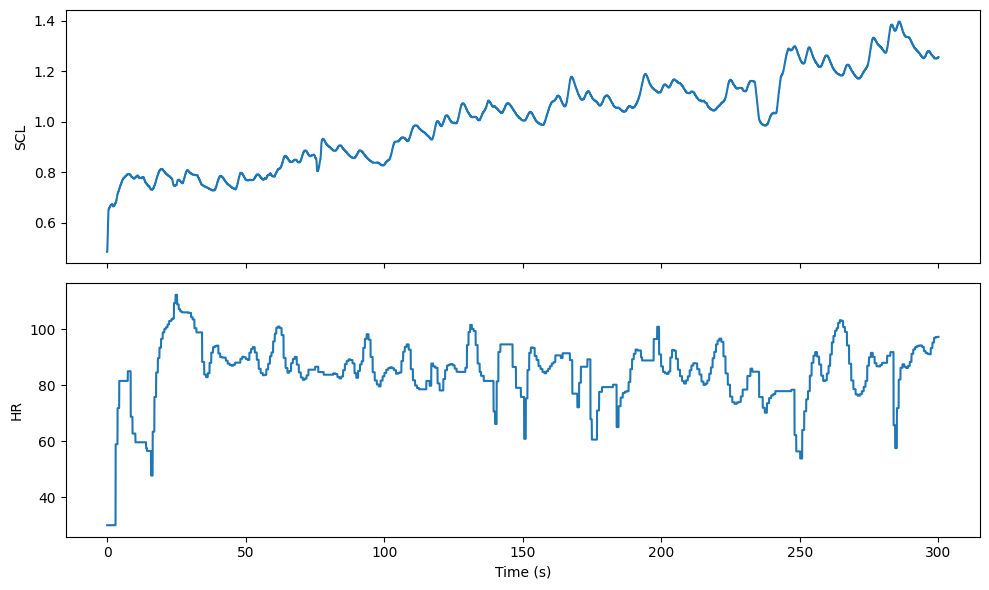

In [11]:
# Plot SCL and HR if present
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for sig, ax in [("SCL", axes[0]), ("HR", axes[1])]:
    df_sig = tidy_df[tidy_df["signal"].str.upper() == sig]
    if not df_sig.empty:
        ax.plot(df_sig["timestamp"].to_numpy(), df_sig["value"].to_numpy())
        ax.set_ylabel(sig)
    else:
        ax.text(0.5, 0.5, f"{sig} not in file", ha="center", va="center")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()


## 10) Notes
- Run once for each session. For meditation, run twice (`METHOD='custom'` and `'conventional'`) and compare paired features.
- You can extend features (e.g., SCR peak detection with thresholds, frequency-domain HRV) if you later have IBI.